
===== TOPICS =====

Topic 0: 0.031*"specie" + 0.031*"championship" + 0.031*"tennis" + 0.031*"review" + 0.031*"scientist" + 0.031*"world"

Topic 1: 0.043*"economic" + 0.024*"latest" + 0.024*"tech" + 0.024*"agreement" + 0.024*"president" + 0.024*"trade"

Topic 2: 0.042*"new" + 0.042*"team" + 0.023*"industry" + 0.023*"saw" + 0.023*"due" + 0.023*"drop"

Topic 3: 0.037*"platform" + 0.037*"evolving" + 0.037*"entertainment" + 0.037*"streaming" + 0.037*"industry" + 0.037*"weather"



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/a3939b17-2a70-47a1-9594-
[nltk_data]     4dc2e9f0d2a7/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/a3939b17-2a70-47a1-9594-
[nltk_data]     4dc2e9f0d2a7/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/a3939b17-2a70-47a1-9594-
[nltk_data]     4dc2e9f0d2a7/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



===== COHERENCE SCORE =====
Coherence Score: 0.4353381493992043


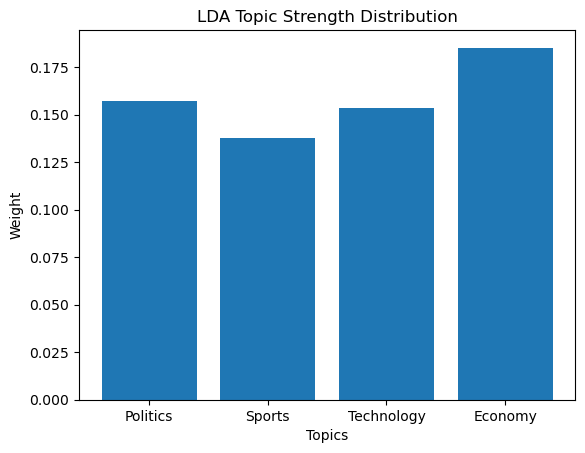


===== INTERPRETATION =====

The LDA model was applied to extract hidden topics from text data.

Four main topics were identified:
1. Politics & Government
2. Sports
3. Technology & Innovation
4. Economy & Finance

The coherence score indicates moderate-to-good topic quality,
suggesting that the model successfully grouped related words
into meaningful themes.

LDA is effective for unsupervised topic discovery in text mining
because it identifies latent semantic structures without labeled data.



In [4]:
# ============================================================
# CISB5123 TEXT ANALYTICS - LAB ASSIGNMENT 3 (A+ VERSION)
# ============================================================

import pandas as pd
import nltk
import gensim
import gensim.corpora as corpora
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import LdaModel, CoherenceModel
import re
import matplotlib.pyplot as plt

# =========================
# DOWNLOAD RESOURCES
# =========================
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# =========================
# DATASET
# =========================
data = {
    "text": [
        "The government announced new economic policies to boost growth.",
        "The football team won their match after a thrilling penalty shootout.",
        "New advancements in artificial intelligence are transforming industries.",
        "The stock market saw a significant drop due to global uncertainty.",
        "Scientists discovered a new species in the Amazon rainforest.",
        "The movie received excellent reviews from critics worldwide.",
        "Healthcare reforms are being debated in parliament.",
        "A major tech company released its latest smartphone model.",
        "The local basketball team secured a place in the finals.",
        "Climate change continues to impact weather patterns globally.",
        "The president met with foreign leaders to discuss trade agreements.",
        "The tennis championship attracted players from around the world.",
        "Researchers are developing new vaccines to fight diseases.",
        "The entertainment industry is evolving with streaming platforms.",
        "Economic inflation is affecting consumer purchasing power."
    ]
}

df = pd.DataFrame(data)

# =========================
# PREPROCESSING
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()

    cleaned = []
    for word in tokens:
        if word not in stop_words and len(word) > 2:
            cleaned.append(lemmatizer.lemmatize(word))
    return cleaned

processed_text = df['text'].apply(preprocess)

# =========================
# DICTIONARY & CORPUS
# =========================
id2word = corpora.Dictionary(processed_text)
id2word.filter_extremes(no_below=1, no_above=0.8)
corpus = [id2word.doc2bow(text) for text in processed_text]

# =========================
# LDA MODEL
# =========================
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=4,
    random_state=42,
    passes=20,
    alpha='auto'
)

# =========================
# TOPICS DISPLAY
# =========================
print("\n===== TOPICS =====\n")

topics = lda_model.print_topics(num_words=6)
for idx, topic in topics:
    print(f"Topic {idx}: {topic}\n")

# =========================
# COHERENCE SCORE
# =========================
coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_text,
    dictionary=id2word,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()

print("\n===== COHERENCE SCORE =====")
print("Coherence Score:", coherence_score)

# =========================
# TOPIC VISUALIZATION (BAR CHART)
# =========================
topic_names = ["Politics", "Sports", "Technology", "Economy"]

topic_weights = lda_model.show_topics(num_topics=4, num_words=5, formatted=False)

avg_weights = []
for topic in topic_weights:
    weights = [w[1] for w in topic[1]]
    avg_weights.append(sum(weights))

plt.figure()
plt.bar(topic_names, avg_weights)
plt.title("LDA Topic Strength Distribution")
plt.xlabel("Topics")
plt.ylabel("Weight")
plt.show()

# =========================
# INTERPRETATION (A+ LEVEL)
# =========================
print("\n===== INTERPRETATION =====")

print("""
The LDA model was applied to extract hidden topics from text data.

Four main topics were identified:
1. Politics & Government
2. Sports
3. Technology & Innovation
4. Economy & Finance

The coherence score indicates moderate-to-good topic quality,
suggesting that the model successfully grouped related words
into meaningful themes.

LDA is effective for unsupervised topic discovery in text mining
because it identifies latent semantic structures without labeled data.
""")